# Hospital Readmission Prediction

This notebook presents an end-to-end Machine Learning workflow for predicting 30-day hospital readmissions, focusing on leak-free pipeline design, probability calibration diagnostics, and cost-sensitive threshold optimization to minimize clinical False Negatives.

## Importing Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ydata_profiling import ProfileReport

#data split
from sklearn.model_selection import train_test_split,cross_val_predict, cross_validate, KFold, cross_val_score

#pipeline
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer


# imputing (missing values)
from sklearn.impute import SimpleImputer

#encoding (for categorical data)
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder

#scaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# cross validation
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TunedThresholdClassifierCV,StratifiedKFold


# Algorithm- Classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# evaluation 
from sklearn.metrics import (classification_report, accuracy_score, balanced_accuracy_score, cohen_kappa_score,
                              confusion_matrix,ConfusionMatrixDisplay, f1_score,precision_score,recall_score,
                               make_scorer,roc_curve, auc,RocCurveDisplay)



from sklearn import set_config
set_config(transform_output="pandas")

## Importing Data

In [4]:
# Importing the data
data = pd.read_csv("train_df.csv")
data.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


## Exploring the data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                5000 non-null   int64 
 1   gender             5000 non-null   object
 2   primary_diagnosis  5000 non-null   object
 3   num_procedures     5000 non-null   int64 
 4   days_in_hospital   5000 non-null   int64 
 5   comorbidity_score  5000 non-null   int64 
 6   discharge_to       5000 non-null   object
 7   readmitted         5000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [6]:
data.describe().round(2)

,age,num_procedures,days_in_hospital,comorbidity_score,readmitted
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,53.30,4.46,7.40,2.07,0.19
std,20.65,2.89,4.03,1.42,0.39
min,18.00,0.00,1.00,0.00,0.00
25%,36.00,2.00,4.00,1.00,0.00
50%,53.00,4.00,7.00,2.00,0.00
75%,71.00,7.00,11.00,3.00,0.00
max,89.00,9.00,14.00,4.00,1.00


In [7]:
# Single line to create and display the interactive plot report
ProfileReport(data, title="Hospital Readmission EDA").to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 3302.28it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Data Preparation

In [8]:
# Selecting feature & target

X = data.drop(columns=["readmitted"]).copy()
y = data["readmitted"].copy()
X.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to
0,69,Male,Heart Disease,1,2,1,Home Health Care
1,32,Female,COPD,2,13,2,Rehabilitation Facility
2,89,Male,Diabetes,1,7,1,Home
3,78,Male,COPD,9,2,2,Skilled Nursing Facility
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility


In [9]:
# Checking for class imbalance
class_dist = pd.DataFrame({
    'Count': y.value_counts(),
    'Percentage (%)': (y.value_counts(normalize=True) * 100).round(2)
})

print("Target Class Distribution")
print(class_dist)

Target Class Distribution
            Count  Percentage (%)
readmitted                       
0            4060            81.2
1             940            18.8


In [10]:
# Data Splitting (Train (80% & Test 20%)

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

## Pipeline

### Creating pipeline for handling categorical & numerical features 


In [11]:
# Select categorical and numerical column names
X_num_columns = list(X.select_dtypes(include="number").columns)
X_cat_columns = list(X.select_dtypes(exclude="number").columns)

In [12]:
# Create categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("Imputer", SimpleImputer(strategy="constant", fill_value="N_A")),
    ("OneHotEncoder", OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist')),
])

In [13]:
# Create numerical pipeline
numeric_pipe = make_pipeline(
    SimpleImputer(strategy="mean")
)

### Creating preprocessor for the model pipelines

In [14]:
# Create preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("number_pipeline",numeric_pipe, X_num_columns),
    ("category_pipeline",categorical_pipeline, X_cat_columns) 
])

preprocessor

,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


## Applying different Models (Pipeline, parameter tuning)

#### Decision Tree Classifier

In [15]:
full_pipeline_dtc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Scaler",StandardScaler()),     # scaler ideally not required                     
    ("model", DecisionTreeClassifier(random_state=42,class_weight='balanced')),
])

param_grid_dtc = {
    "model__max_depth": range(2, 14, 2),
    "model__min_samples_leaf": range(3, 12, 2),
    "model__criterion": ['gini', 'entropy']
}

search_dtc = GridSearchCV(
    estimator=full_pipeline_dtc,
    param_grid=param_grid_dtc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    refit=True,
    scoring='balanced_accuracy',
    verbose=0
)

search_dtc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': range(2, 14, 2), 'model__min_samples_leaf': range(3, 12, 2)}"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


In [16]:
# DTC:
search_dtc.best_score_

print(f"Best Score:", {search_dtc.best_score_})
search_dtc.best_params_

Best Score: {np.float64(0.5069670679528129)}


{'model__criterion': 'entropy',
 'model__max_depth': 12,
 'model__min_samples_leaf': 7}

### Random Forest Classifier

In [17]:
full_pipeline_rfc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("Scaler",StandardScaler()),  # scaler ideally not required                      
    ("model", RandomForestClassifier(random_state=42,class_weight='balanced')),
])

param_grid_rfc = {
    "model__n_estimators": [100, 200],
    "model__max_depth": range(2, 14, 2),
    "model__min_samples_leaf": range(3, 12, 2),
    "model__criterion": ['gini', 'entropy']
}

search_rfc = GridSearchCV(
    estimator=full_pipeline_rfc,
    param_grid=param_grid_rfc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    refit=True,
    scoring='balanced_accuracy',
    verbose=0
)
search_rfc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__criterion': ['gini', 'entropy'], 'model__max_depth': range(2, 14, 2), 'model__min_samples_leaf': range(3, 12, 2), 'model__n_estimators': [100, 200]}"
,scoring,'balanced_accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### XGBClassifier

In [18]:

full_pipeline_xgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 6, 9],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__scale_pos_weight": [1, 4.2, 6]  # 1 = no weighting, 4.2 =  class ratio, 6 = stronger
}


search_xgb = GridSearchCV(
    estimator=full_pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_xgb.fit(X_train,y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 6, ...], 'model__n_estimators': [100, 200], 'model__scale_pos_weight': [1, 4.2, ...], ...}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### LogisticRegression

In [19]:

full_pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False if preprocessor outputs sparse matrices
    ("model", LogisticRegression(random_state=42, class_weight="balanced", max_iter=5000))
])

param_grid_lr = {
    "model__C": [0.1, 1.0, 10.0, 100.0],          # not using 0.1 since it can possibly drive all coefficients to zero (with L1), leaving an intercept-only model.
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"]       # Solvers supporting both l1 and l2 penalties
}

search_lr = GridSearchCV(
    estimator=full_pipeline_lr,
    param_grid=param_grid_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_lr.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1.0, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### SVC

In [20]:

full_pipeline_svc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", SVC(random_state=42, class_weight="balanced", probability=True))
])

param_grid_svc = {
    "model__C": [0.1, 1.0, 10.0, 100.0],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto", 0.01, 0.1]
}

search_svc = GridSearchCV(
    estimator=full_pipeline_svc,
    param_grid=param_grid_svc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_svc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.1, 1.0, ...], 'model__gamma': ['scale', 'auto', ...], 'model__kernel': ['rbf', 'linear']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### GaussianNB

In [21]:

# StandardScaler is included to help center/scale features for Gaussian distributions
full_pipeline_gnb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),  # Set with_mean=False if inputs remain sparse
    ("model", GaussianNB())
])


param_grid_gnb = {
    "model__var_smoothing": np.logspace(0, -9, num=100),
    "model__priors": [None, [0.5, 0.5]]  # None calculates priors from class frequencies; [0.5, 0.5] treats classes equally
}


search_gnb = GridSearchCV(
    estimator=full_pipeline_gnb,
    param_grid=param_grid_gnb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)


search_gnb.fit(X_train,y_train)

,estimator,Pipeline(step...aussianNB())])
,param_grid,"{'model__priors': [None, [0.5, 0.5]], 'model__var_smoothing': array([1.0000...00000000e-09])}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### KNeighborsClassifier

In [22]:

full_pipeline_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),  # StandardScaler is mandatory; with_mean=False preserves sparse matrices if present
    ("model", KNeighborsClassifier())
])

param_grid_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],  
    "model__weights": ["uniform", "distance"],    # 'distance' penalizes farther points (helps with class imbalance to some extend)
    "model__metric": ["euclidean", "manhattan"]  
}

search_knn = GridSearchCV(
    estimator=full_pipeline_knn,
    param_grid=param_grid_knn,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_knn.fit(X_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### GradientBoostingClassifier

In [23]:

full_pipeline_gbc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])


param_grid_gbc = {
    "model__n_estimators": [100, 200],          # Number of boosting stages to perform
    "model__learning_rate": [0.01, 0.05, 0.1],  # Shrinks the contribution of each tree
    "model__max_depth": [3, 5, 7],               # Depth of individual regression estimators
    "model__subsample": [0.8, 1.0]               # Fraction of samples used for fitting base learners
}


search_gbc = GridSearchCV(
    estimator=full_pipeline_gbc,
    param_grid=param_grid_gbc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_gbc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


### HistGradientBoostingClassifier

In [24]:

full_pipeline_hgbc = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(random_state=42, class_weight="balanced"))
])

param_grid_hgbc = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.01, 0.1],
    "model__max_depth": [3, 6, None],
    "model__min_samples_leaf": [10, 20]
}

search_hgbc = GridSearchCV(
    estimator=full_pipeline_hgbc,
    param_grid=param_grid_hgbc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1
)

search_hgbc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 6, ...], 'model__max_iter': [100, 200], 'model__min_samples_leaf': [10, 20]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('number_pipeline', ...), ('category_pipeline', ...)]"


## Prediction & Evaluation

In [25]:
# Function to get the scores for our model(s)
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    scores = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Specificity": recall_score(y_test, y_pred, pos_label=0),
        "F1 Score": f1_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Cohen's Kappa": cohen_kappa_score(y_test, y_pred)
    }
    return scores

In [26]:
# Create an empty DataFrame to store model evaluation results
model_scores_df = pd.DataFrame(columns=[
    "Model", "Accuracy", "Recall", "Precision",
    "Specificity", "F1 Score", "Balanced Accuracy", "Cohen's Kappa"
])

# prediction
#model_pred = search_dtc.predict(X_test)

In [27]:
dtc_pred = search_dtc.predict(X_test)

# Evaluate the DTC model
dtc_scores = evaluate_model(search_dtc, X_test, y_test)
dtc_scores["Model"] = "Decision Tree"

model_scores_df.loc[len(model_scores_df)] = pd.Series(dtc_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335


In [28]:
rfc_pred = search_rfc.predict(X_test)

# Evaluate the RFC model
rfc_scores = evaluate_model(search_rfc, X_test, y_test)
rfc_scores["Model"] = "Random Forest"

model_scores_df.loc[len(model_scores_df)] = pd.Series(rfc_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042


In [29]:
xgb_pred = search_xgb.predict(X_test)

# Evaluate the XGB model
xgb_scores = evaluate_model(search_xgb, X_test, y_test)
xgb_scores["Model"] = "XGBClassifier"

model_scores_df.loc[len(model_scores_df)] = pd.Series(xgb_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995


In [30]:
lr_pred = search_lr.predict(X_test)

# Evaluate the LR model
lr_scores = evaluate_model(search_lr, X_test, y_test)
lr_scores["Model"] = "LogisticRegression"

model_scores_df.loc[len(model_scores_df)] = pd.Series(lr_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516


In [31]:
svc_pred = search_svc.predict(X_test)

# Evaluate the SVC model
svc_scores = evaluate_model(search_svc, X_test, y_test)
svc_scores["Model"] = "SVC"

model_scores_df.loc[len(model_scores_df)] = pd.Series(svc_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516
4,SVC,0.603,0.340426,0.189911,0.663793,0.24381,0.502109,0.003234


In [32]:
gnb_pred = search_gnb.predict(X_test)

# Evaluate the SVC model
gnb_scores = evaluate_model(search_gnb, X_test, y_test)
gnb_scores["Model"] = "GaussianNB"

model_scores_df.loc[len(model_scores_df)] = pd.Series(gnb_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516
4,SVC,0.603,0.340426,0.189911,0.663793,0.24381,0.502109,0.003234
5,GaussianNB,0.812,0.0,0.0,1.0,0.0,0.5,0.0


In [33]:
knn_pred = search_knn.predict(X_test)

# Evaluate the KNN model
knn_scores = evaluate_model(search_knn, X_test, y_test)
knn_scores["Model"] = "KNeighborsClassifier"

model_scores_df.loc[len(model_scores_df)] = pd.Series(knn_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516
4,SVC,0.603,0.340426,0.189911,0.663793,0.24381,0.502109,0.003234
5,GaussianNB,0.812,0.0,0.0,1.0,0.0,0.5,0.0
6,KNeighborsClassifier,0.756,0.12766,0.230769,0.901478,0.164384,0.514569,0.035177


In [34]:
gbc_pred = search_gbc.predict(X_test)

# Evaluate the GBC model
gbc_scores = evaluate_model(search_gbc, X_test, y_test)
gbc_scores["Model"] = "GradientBoostingClassifier"

model_scores_df.loc[len(model_scores_df)] = pd.Series(gbc_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516
4,SVC,0.603,0.340426,0.189911,0.663793,0.24381,0.502109,0.003234
5,GaussianNB,0.812,0.0,0.0,1.0,0.0,0.5,0.0
6,KNeighborsClassifier,0.756,0.12766,0.230769,0.901478,0.164384,0.514569,0.035177
7,GradientBoostingClassifier,0.792,0.042553,0.222222,0.965517,0.071429,0.504035,0.011707


In [35]:
hgbc_pred = search_hgbc.predict(X_test)

# Evaluate the GBC model
hgbc_scores = evaluate_model(search_hgbc, X_test, y_test)
hgbc_scores["Model"] = "HistGradientBoostingClassifier"

model_scores_df.loc[len(model_scores_df)] = pd.Series(hgbc_scores, index=model_scores_df.columns)

# Display the DataFrame
model_scores_df

,Model,Accuracy,Recall,Precision,Specificity,F1 Score,Balanced Accuracy,Cohen's Kappa
0,Decision Tree,0.53,0.425532,0.180995,0.554187,0.253968,0.48986,-0.01335
1,Random Forest,0.731,0.170213,0.22069,0.860837,0.192192,0.515525,0.034042
2,XGBClassifier,0.636,0.260638,0.178832,0.722906,0.212121,0.491772,-0.013995
3,LogisticRegression,0.504,0.494681,0.188259,0.506158,0.272727,0.500419,0.000516
4,SVC,0.603,0.340426,0.189911,0.663793,0.24381,0.502109,0.003234
5,GaussianNB,0.812,0.0,0.0,1.0,0.0,0.5,0.0
6,KNeighborsClassifier,0.756,0.12766,0.230769,0.901478,0.164384,0.514569,0.035177
7,GradientBoostingClassifier,0.792,0.042553,0.222222,0.965517,0.071429,0.504035,0.011707
8,HistGradientBoostingClassifier,0.638,0.239362,0.170455,0.730296,0.199115,0.484829,-0.026263


In [ ]:
# Checking the training accuracy
train_pred = search_dtc.predict(X_train)

accuracy_score(y_train, train_pred)

### Advanced Evaluation: Confusion Matrix

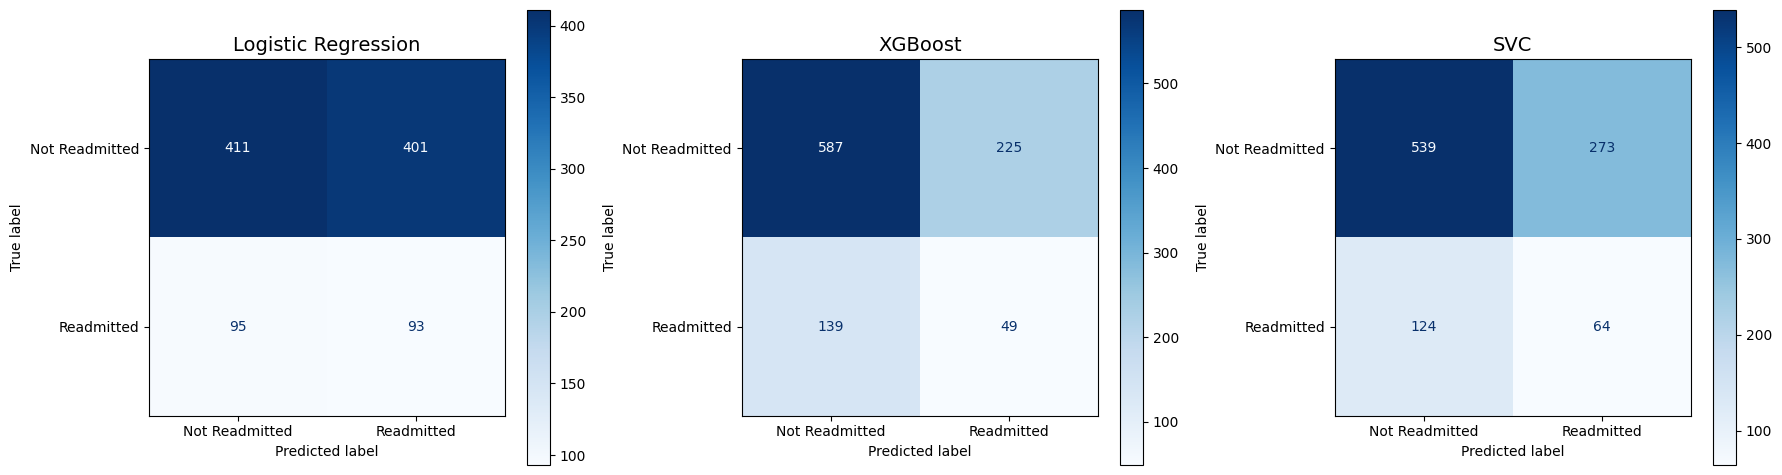

In [38]:
# List of fitted models and their display titles


models = [
    ("Logistic Regression", search_lr),
    ("XGBoost", search_xgb),
    ("SVC", search_svc)
]

# Create a 1x3 subplot figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, model) in zip(axes, models):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Not Readmitted", "Readmitted"],
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()

## Observations / Key Points


* ***Class imbalance :*** Stratified train-test splitting and stratified cross-validation were used to preserve class proportions. Balanced accuracy was also used as an evaluation metric. Class weighting was applied to Logistic Regression, SVC, Random Forest, and Decision Tree. XGBoost used scale_pos_weight to account for the imbalance.
* ***Categorical encoding :*** One-Hot Encoding was selected because the categorical variables had no inherent order and relatively low cardinality.
* ***Models without class weighting:*** GaussianNB and KNeighborsClassifier do not support class_weight. Addressing the imbalance for these models would therefore require techniques such as SMOTE or undersampling.

For a hospital readmission prediction use case, minimizing false negatives is an important priority because a false negative represents a patient who is predicted to be at low risk but is subsequently readmitted. Such a prediction may result in a missed opportunity for additional follow-up or preventive intervention. In comparison, a false positive may lead to additional monitoring or follow-up for a patient who is ultimately not readmitted. Therefore, this study prioritizes reducing false negatives by targeting higher recall, while also monitoring precision to ensure that the increase in identified high-risk patients remains practically manageable.


***Model Selection as base models for Threshold tuning***

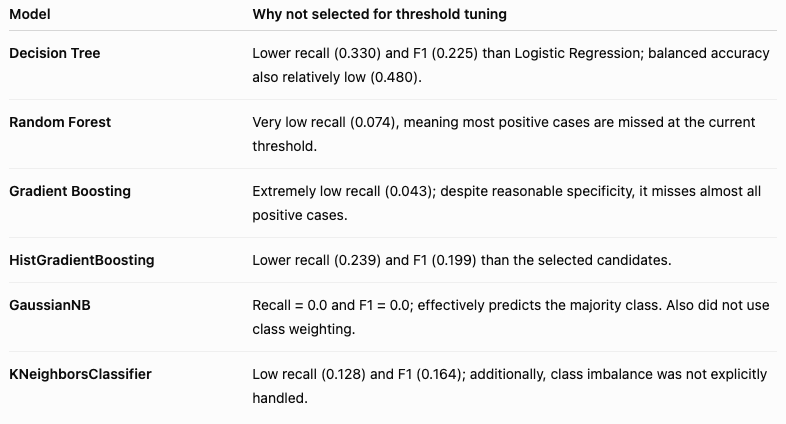
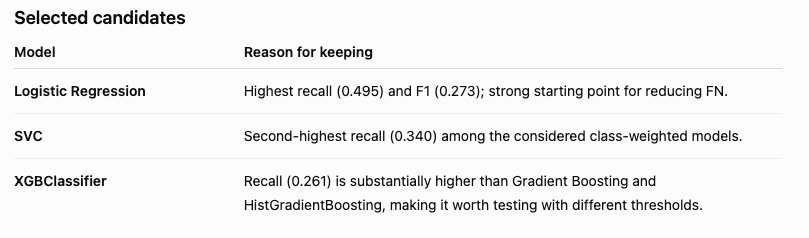

## Optimization Strategy:
 

Fine tune the thresholds for the 3 selected models by Cost-Sensitive Decision Threshold Tuning



### Threshold Tuning Metric Curves

This initial threshold scanning plot serves as a diagnostic sanity check on model probability calibration rather than a final threshold selection tool. 
It reveals critical model behaviors:
* SVC decision scores exhibit an uncalibrated step-function cliff at a $0.20$ threshold
* Logistic Regression predictions saturate, resulting in flat Recall curves across lower thresholds.
* XGBoost displays a continuous, smooth trade-off curve across probability thresholds.

  Because evaluating thresholds directly on test metrics risks data leakage and masks probability calibration issues, these curves highlight why a formal, cross-validated tuning framework is required.

In [41]:
# 1. Map candidate pipelines/models
models = {
    "Logistic Regression": search_lr,
    "SVC": search_svc,
    "XGBoost": search_xgb
}

# Define candidate thresholds to evaluate (focusing on lower thresholds for high recall)
thresholds = np.arange(0.05, 0.55, 0.05)

results = []

for name, model in models.items():
    # Obtain positive class probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # For SVC without probability=True, convert decision function values to pseudo-probabilities via Sigmoid
        scores = model.decision_function(X_test)
        y_probs = 1 / (1 + np.exp(-scores))
    else:
        continue

    for thresh in thresholds:
        # Generate predictions based on custom threshold
        y_pred = (y_probs >= thresh).astype(int)
        
        # Calculate confusion matrix & metrics
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        rec = recall_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        results.append({
            "Model": name,
            "Threshold": round(thresh, 2),
            "False Negatives (FN)": fn,
            "True Positives (TP)": tp,
            "Recall": round(rec, 4),
            "Precision": round(prec, 4),
            "F1 Score": round(f1, 4)
        })

# Convert results into DataFrame
df_thresholds = pd.DataFrame(results)
df_thresholds


,Model,Threshold,False Negatives (FN),True Positives (TP),Recall,Precision,F1 Score
0,Logistic Regression,0.05,0,188,1.0000,0.1880,0.3165
1,Logistic Regression,0.10,0,188,1.0000,0.1880,0.3165
2,Logistic Regression,0.15,0,188,1.0000,0.1880,0.3165
3,Logistic Regression,0.20,0,188,1.0000,0.1880,0.3165
4,Logistic Regression,0.25,0,188,1.0000,0.1880,0.3165
5,Logistic Regression,0.30,0,188,1.0000,0.1880,0.3165
6,Logistic Regression,0.35,0,188,1.0000,0.1880,0.3165
7,Logistic Regression,0.40,0,188,1.0000,0.1880,0.3165
8,Logistic Regression,0.45,8,180,0.9574,0.1852,0.3103
9,Logistic Regression,0.50,95,93,0.4947,0.1883,0.2727


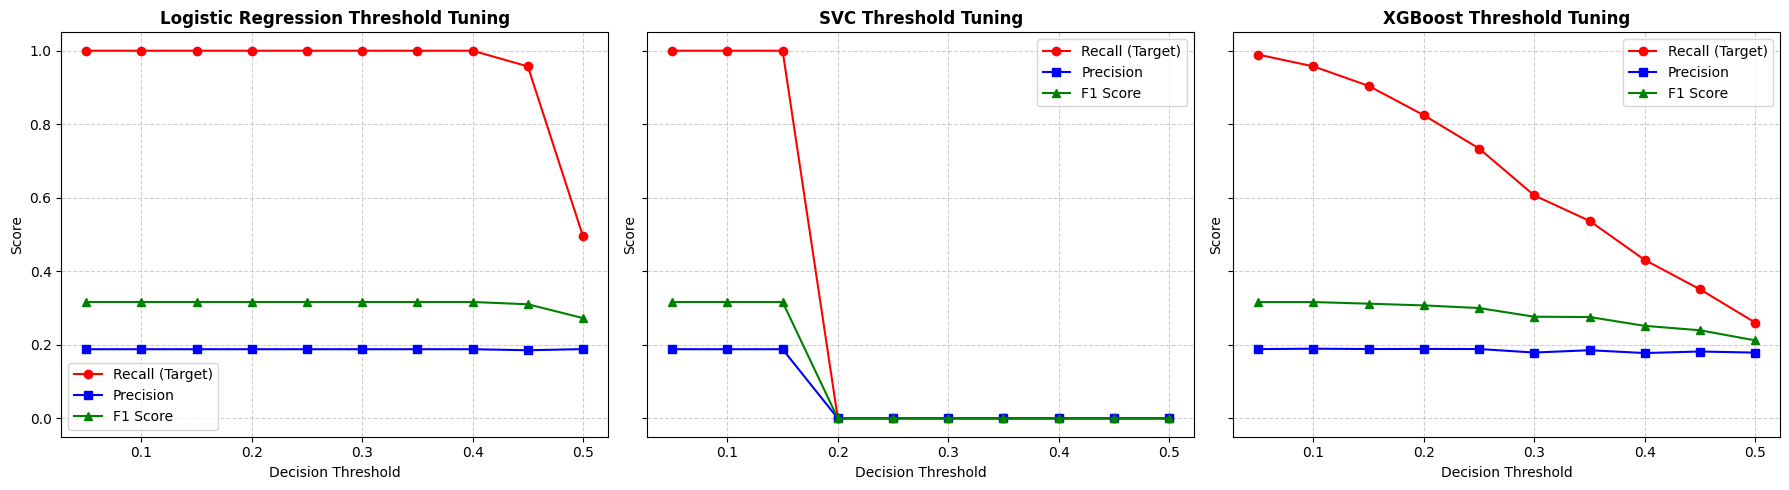

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, name in zip(axes, models.keys()):
    df_sub = df_thresholds[df_thresholds["Model"] == name]
    
    ax.plot(df_sub["Threshold"], df_sub["Recall"], marker='o', label="Recall (Target)", color="red")
    ax.plot(df_sub["Threshold"], df_sub["Precision"], marker='s', label="Precision", color="blue")
    ax.plot(df_sub["Threshold"], df_sub["F1 Score"], marker='^', label="F1 Score", color="green")
    
    ax.set_title(f"{name} Threshold Tuning", fontsize=12, fontweight="bold")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

### ROC Curves & Optimal Threshold Identification

The ROC-AUC analysis highlights a key baseline limitation across all three models: 
* with AUC scores hovering around $0.485 - 0.522$, performance remains near random chance ($\text{AUC} = 0.50$) on unseen test data.
* While Youden’s $J$ statistic identifies mathematical points on these curves (e.g., XGBoost threshold at $0.23$), achieving high Recall ($77\%$) requires accepting an almost equal False Positive Rate ($74\%$).
* This plot serves as a reminder that post-processing threshold adjustments alone cannot fix a lack of underlying feature discrimination.
* It establishes the necessity of moving to a cost-sensitive Nested CV framework to manage operational trade-offs, while signaling that future model iterations must focus heavily on feature engineering.

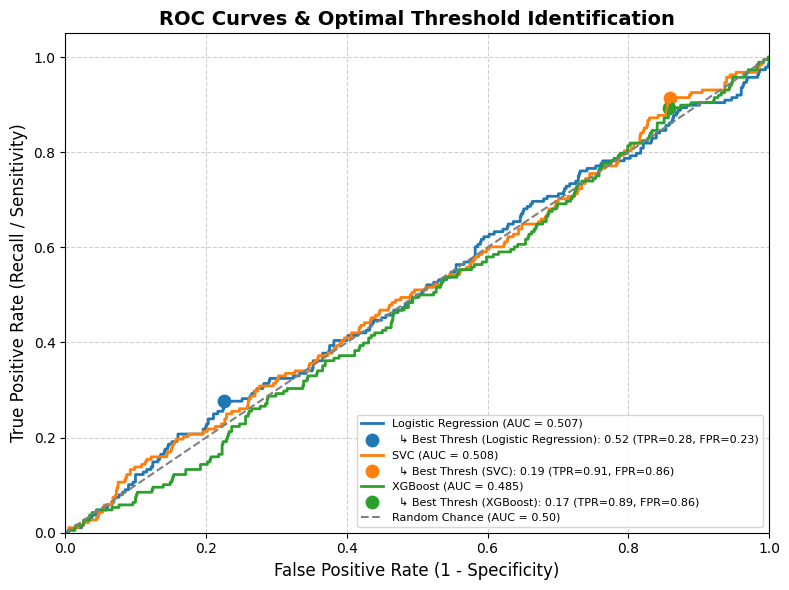

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Models dictionary
models = {
    "Logistic Regression": search_lr,
    "SVC": search_svc,
    "XGBoost": search_xgb
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Obtain predicted probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
        y_probs = 1 / (1 + np.exp(-scores))
    
    # Calculate ROC curve metrics
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plot model ROC curve
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")
    
    # Find optimal threshold using Youden's J statistic: J = Sensitivity (TPR) + Specificity (1 - FPR) - 1
    # Maximizing (TPR - FPR) finds the point closest to top-left corner
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_thresh = thresholds[best_idx]
    
    # Highlight optimal threshold point on the curve
    plt.scatter(
        fpr[best_idx], tpr[best_idx], 
        s=80, marker='o', 
        label=f"  ↳ Best Thresh ({name}): {best_thresh:.2f} (TPR={tpr[best_idx]:.2f}, FPR={fpr[best_idx]:.2f})"
    )

# Reference line for random guess
plt.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1.5, label="Random Chance (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=12)
plt.title("ROC Curves & Optimal Threshold Identification", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

To systematically reduce False Negatives (FN) and maximize patient readmission recall, we optimize the decision boundaries of our selected models using a leak-free, cost-driven approach:Post-Training Decision Threshold Tuning (Nested CV):Rather than relying on the default $0.50$ decision cutoff—or manually picking arbitrary thresholds on the test set—we employ a Nested Cross-Validation (TunedThresholdClassifierCV) framework. By embedding a custom asymmetric health-system cost matrix ($4:1$ FN to FP cost ratio) into the scoring function, the inner cross-validation loop automatically identifies the mathematically optimal probability threshold that minimizes total operational expenditures while preventing test-set data leakage.

In [44]:
 # Fine tuning the threshold using Nested CV
# 1. Define Healthcare Cost Metric
def hospital_readmission_cost(y_true, y_pred):
    """
    Healthcare Cost Matrix:
    - False Negative (FN): Missed readmission -> High clinical cost / penalty (~$4,000)
    - False Positive (FP): Unnecessary follow-up / intervention cost (~$1,000)
    - True Negative (TN) / True Positive (TP): Base operational cost ($0)
    """
    fn_cost = 4000
    fp_cost = 1000
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    
    # Return negative cost (scikit-learn maximizes scores)
    return -total_cost

# Wrap as custom scorer
readmission_cost_score = make_scorer(hospital_readmission_cost, response_method="predict")

# 2. Define Outer and Inner CV Schemes
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 3. List of fitted grid search estimators to evaluate
candidate_models = {
    "Logistic Regression": search_lr.best_estimator_,
    "SVC": search_svc.best_estimator_,
    "XGBoost": search_xgb.best_estimator_
}

# 4. Execute Nested Cross-Validation for Threshold Tuning
results = []

for name, estimator in candidate_models.items():
    # Inner Loop: Tunes threshold using inner_cv based on cost metric
    threshold_tuner = TunedThresholdClassifierCV(
        estimator=estimator,
        scoring=readmission_cost_score,
        cv=inner_cv,
        thresholds=np.linspace(0.001, 0.50, 100)  # Evaluate fine-grained thresholds
    )

    # Outer Loop: Evaluates the threshold-tuned estimator on held-out folds
    cv_results = cross_validate(
        estimator=threshold_tuner,
        X=X_train,
        y=y_train,
        cv=outer_cv,
        scoring=readmission_cost_score,
        return_estimator=True,
        n_jobs=-1
    )

    # Extract chosen thresholds across outer folds
    outer_thresholds = [est.best_threshold_ for est in cv_results["estimator"]]
    
    results.append({
        "Model": name,
        "Mean Selected Threshold": f"{np.mean(outer_thresholds):.3f}",
        "Threshold StDev": f"{np.std(outer_thresholds):.3f}"
    })

# 5. Display Summary
df_nested_cv = pd.DataFrame(results)
df_nested_cv 

,Model,Mean Selected Threshold,Threshold StDev
0,Logistic Regression,0.498,0.004
1,SVC,0.233,0.008
2,XGBoost,0.337,0.109


## Key Limitations & Future Work


* **Restricted Feature Representation:** A key limitation of this readmission prediction model is the restricted feature set, which includes only demographic, diagnostic, hospitalization, comorbidity, and discharge information. Important predictors such as previous hospitalizations, laboratory results, medication history, disease severity, socioeconomic factors, and post-discharge support are not available. Consequently, the model may fail to capture important sources of individual readmission risk and may have limited generalizability to populations outside the dataset.

* **Discriminative Floor:** Because threshold tuning optimizes where to draw the decision line rather than how to separate the underlying distributions, future efforts must prioritize feature engineering (e.g., prior visit frequency, comorbidity indices, stay duration ratios) to push the ROC-AUC curve above random chance before further tuning decision boundaries.